# Pure ConvTran 1 Second Model

This version is optimized for maximum speed:
- **Epochs**: 20
- **Training Data**: Time Series capped at 1 second per observation.

In [11]:
import os, sys, gc, logging, copy, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

# Basic setup & Paths
PROJECT_ROOT = Path.cwd().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'ConvTran'))

from src.utils import SEED, set_global_seed
from src.utils.paths import ensure_dir, get_experiment_dir, get_experiment_output_dir
from src.data import CLASS_NAMES, load_labels, load_raw_dataset, normalize_per_sample
from src.data.splits import load_splits
from src.training.evaluation import compute_metrics
from Models.model import model_factory

logging.basicConfig(level=logging.INFO)
NUM_CLASSES = len(CLASS_NAMES)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
# 1. Load & Subsample Data
idx_train_orig, idx_val_orig, idx_test = load_splits()
X_full, y_full = load_raw_dataset()
y_idx = np.argmax(y_full, axis=1) if y_full.ndim == 2 else y_full

print("Cleaning & Normalizing data...")
X_full = np.nan_to_num(X_full)
X_full = normalize_per_sample(X_full, axis=-1)
X_full = np.nan_to_num(X_full)

def subsample(indices, samples_per_class):
    X_sub = X_full[indices]
    y_sub = y_idx[indices]
    counts = Counter(y_sub)
    min_size = min(min(counts.values()), samples_per_class)
    
    final_idx = []
    np.random.seed(SEED)
    for cls in range(NUM_CLASSES):
        cls_map = np.where(y_sub == cls)[0]
        final_idx.extend(np.random.choice(cls_map, min_size, replace=False))
    np.random.shuffle(final_idx)
    return X_sub[final_idx], y_sub[final_idx]

# print("Subsampling Train (250/class) and Val (100/class) for speed...")
# X_train, y_train = subsample(idx_train_orig, 250)
# X_val, y_val = subsample(idx_val_orig, 100)
# X_test, y_test = X_full[idx_test], y_idx[idx_test]
# 1. Use ALL original data instead of subsampling
print("Loading FULL dataset (No subsampling)...")
X_train, y_train = X_full[idx_train_orig], y_idx[idx_train_orig]
X_val, y_val = X_full[idx_val_orig], y_idx[idx_val_orig]
X_test, y_test = X_full[idx_test], y_idx[idx_test]

# Optional: Clean any NaNs (Highly recommended for full raw data)
X_train = np.nan_to_num(X_train)
X_val = np.nan_to_num(X_val)

print(f"Full Shapes: Train={X_train.shape}, Val={X_val.shape}")

# Cut 5,000 points down to 500 (first 1 second)
X_train = X_train[:, :, :500]
X_val = X_val[:, :, :500]
X_test = X_test[:, :, :500]

print(f"Final Shapes: Train={X_train.shape}, Val={X_val.shape}")

INFO:src.data.io:Loaded cached dataset C:\Users\hmanasi1\Documents\deeplearning\Deep-Learning-Project\data\processed\chapman_wfdb_Xy.npz | X=(45150, 12, 5000) y=(45150, 4) | 32.10s


Cleaning & Normalizing data...
Loading FULL dataset (No subsampling)...
Full Shapes: Train=(36120, 12, 5000), Val=(2257, 12, 5000)
Final Shapes: Train=(36120, 12, 500), Val=(2257, 12, 500)


In [13]:
# 2. Stable Config
set_global_seed(SEED)
cond_name = "Pure_ConvTran_Full_2sec"
exp_dir = ensure_dir(get_experiment_dir(cond_name))
ckpt_dir = ensure_dir(get_experiment_output_dir(cond_name, checkpoints=True))
ckpt_path = ckpt_dir / "model.pt"
history_path = ckpt_dir / "history.json"

config = {
    'Net_Type': ['C-T'], 'emb_size': 16, 'dim_ff': 256, 'num_heads': 8,
    'Fix_pos_encode': 'tAPE', 'Rel_pos_encode': 'eRPE', 'dropout': 0.1,
    'Data_shape': X_train.shape, 'num_labels': NUM_CLASSES
}
model = model_factory(config).to(device)
LR, BATCH_SIZE, EPOCHS, PATIENCE = 5e-5, 8, 20, 3
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

history = {'train_loss': [], 'val_f1': []}
best_val_f1 = -1
best_wts = copy.deepcopy(model.state_dict())

INFO:src.utils.seed:Global seed set to 0


In [14]:
# 3. Training/Val Loops
try:
    for ep in range(EPOCHS):
        model.train()
        loss_sum, nb = 0, 0
        pbar = tqdm(range(0, len(X_train), BATCH_SIZE), desc=f"Ep {ep+1} [Train]")
        for start in pbar:
            bx = torch.from_numpy(X_train[start:start+BATCH_SIZE]).float().to(device)
            by = torch.from_numpy(y_train[start:start+BATCH_SIZE]).long().to(device)
            
            opt.zero_grad()
            loss = F.cross_entropy(model(bx), by)
            if torch.isnan(loss): continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=4.0)
            opt.step()
            
            loss_sum += loss.item(); nb += 1
            pbar.set_postfix(loss=loss_sum/nb)

        model.eval()
        preds = []
        v_bar = tqdm(range(0, len(X_val), 16), desc=f"Ep {ep+1} [Val]", leave=False)
        with torch.no_grad():
            for v in v_bar:
                bv = torch.from_numpy(X_val[v:v+16]).float().to(device)
                preds.append(model(bv).argmax(1).cpu().numpy())
        
        f1 = float(compute_metrics(y_val, np.concatenate(preds), task='multiclass', labels=list(range(NUM_CLASSES)))['weighted_f1'])
        history['train_loss'].append(float(loss_sum/nb))
        history['val_f1'].append(f1)
        print(f"  -> Val F1: {f1:.4f}")
        
        if f1 > best_val_f1:
            best_val_f1, best_wts = f1, copy.deepcopy(model.state_dict())
            torch.save({'epoch': ep, 'model_state': model.state_dict(), 'best_val_f1': best_val_f1}, ckpt_path)
finally:
    model.load_state_dict(best_wts)
    with open(history_path, 'w') as f: json.dump(history, f, indent=2)
    torch.cuda.empty_cache(); gc.collect()

Ep 1 [Train]: 100%|████████████████████████████████████████████████████| 4515/4515 [10:26<00:00,  7.21it/s, loss=0.966]
                                                                                                                       

  -> Val F1: 0.6049


Ep 2 [Train]: 100%|████████████████████████████████████████████████████| 4515/4515 [10:40<00:00,  7.04it/s, loss=0.775]
                                                                                                                       

  -> Val F1: 0.6868


Ep 3 [Train]: 100%|████████████████████████████████████████████████████| 4515/4515 [10:43<00:00,  7.02it/s, loss=0.683]
                                                                                                                       

...

  -> Val F1: 0.8048


Ep 19 [Train]: 100%|███████████████████████████████████████████████████| 4515/4515 [06:40<00:00, 11.27it/s, loss=0.491]
                                                                                                                       

  -> Val F1: 0.8036


Ep 20 [Train]: 100%|███████████████████████████████████████████████████| 4515/4515 [06:11<00:00, 12.14it/s, loss=0.487]
                                                                                                                       

  -> Val F1: 0.8085


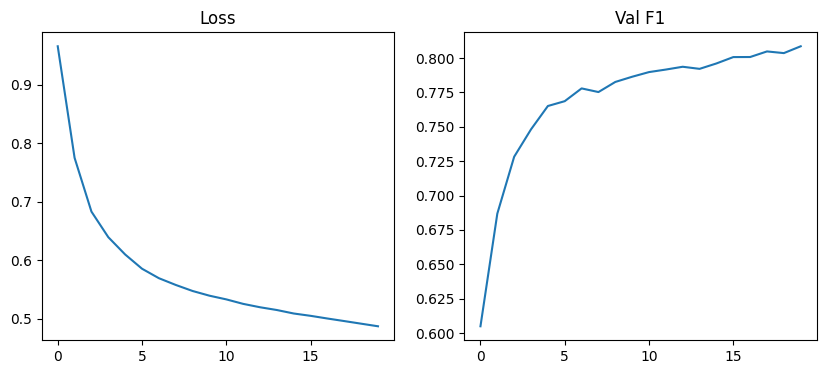

Final Testing...

Test F1: 0.8116


In [15]:
# 4. Plot & Final Test
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history['train_loss']); plt.title('Loss')
plt.subplot(1, 2, 2); plt.plot(history['val_f1']); plt.title('Val F1')
plt.show()

print("Final Testing...")
model.eval()
preds_ts = []
with torch.no_grad():
    for t in range(0, len(X_test), 16):
        bt = torch.from_numpy(X_test[t:t+16]).float().to(device)
        preds_ts.append(model(bt).argmax(1).cpu().numpy())
ts_mets = compute_metrics(y_test, np.concatenate(preds_ts), task='multiclass', labels=list(range(NUM_CLASSES)))
print("\nTest F1: %.4f" % ts_mets['weighted_f1'])
with open(exp_dir / 'final_metrics.json', 'w') as f:
    json.dump({k: float(v) if not isinstance(v, (dict, list, str)) else v for k,v in ts_mets.items()}, f, indent=2)

In [16]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, classification_report

# 1. Run Final Prediction
model.eval()
all_preds = []
with torch.no_grad():
    # evaluate in small batches to save GPU memory
    for start in range(0, len(X_test), 16):
        batch_x = torch.from_numpy(X_test[start:start+16]).float().to(device)
        logits = model(batch_x)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())

y_pred = np.concatenate(all_preds)

# 2. Calculate Overall (Weighted) Metrics
p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

# 3. Calculate Per-Class Metrics
p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=list(range(NUM_CLASSES)))

# 4. Format into a clean DataFrame
results_data = []

# Add Row for Overall
results_data.append({
    'Metric Type': 'OVERALL (Weighted)',
    'Precision': p_w,
    'Recall': r_w,
    'F1-Score': f1_w
})

# Add Rows for Each Class
for i, class_name in enumerate(CLASS_NAMES):
    results_data.append({
        'Metric Type': f'Class: {class_name}',
        'Precision': p_cls[i],
        'Recall': r_cls[i],
        'F1-Score': f1_cls[i]
    })

df_eval = pd.DataFrame(results_data)

# 5. Display Result
print("\n--- ConvTran Evaluation Summary ---")
display(df_eval)

# Optional: Print the full detailed text report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Save results to CSV in the experiment directory
output_csv = exp_dir / 'detailed_test_metrics.csv'
df_eval.to_csv(output_csv, index=False)
print(f"\nResults also saved to: {output_csv}")



--- ConvTran Evaluation Summary ---


C:\Users\hmanasi1\AppData\Local\anaconda3\envs\dl_project\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hmanasi1\AppData\Local\anaconda3\envs\dl_project\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Metric Type,Precision,Recall,F1-Score
0,OVERALL (Weighted),0.803775,0.824007,0.811644
1,Class: AF,0.870499,0.841929,0.855975
2,Class: SVT,0.000000,0.000000,0.000000
3,Class: Sinus Brady,0.812789,0.943505,0.873282
4,Class: Sinus Rhythm,0.728037,0.649167,0.686344



Detailed Classification Report:
              precision    recall  f1-score   support

          AF       0.87      0.84      0.86      2986
         SVT       0.00      0.00      0.00       162
 Sinus Brady       0.81      0.94      0.87      2425
Sinus Rhythm       0.73      0.65      0.69      1200

    accuracy                           0.82      6773
   macro avg       0.60      0.61      0.60      6773
weighted avg       0.80      0.82      0.81      6773


Results also saved to: C:\Users\hmanasi1\Documents\deeplearning\Deep-Learning-Project\experiments\Pure_ConvTran_Full_2sec\detailed_test_metrics.csv


C:\Users\hmanasi1\AppData\Local\anaconda3\envs\dl_project\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hmanasi1\AppData\Local\anaconda3\envs\dl_project\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hmanasi1\AppData\Local\anaconda3\envs\dl_project\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war